<a href="https://colab.research.google.com/github/heyitzrizki/Global-Market-Monitoring-with-LSTM/blob/main/notebook/Global_Market_Monitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Market Monitoring Dashboard
This project builds a real-time analytics dashboard to monitor key global financial indicators such as:
- FX rates (e.g., USD/KRW, USD/JPY, USD/CNY)
- Global volatility index (VIX)
- Commodities (Oil, Gold)
- Macro trends affecting international banking operations

This portfolio demonstrates:
- Ability to collect and analyze real-world financial data
- Understanding of global market dynamics relevant to banking strategy
- Application of ML techniques (PCA, forecasting)
- Building decision-support dashboards for Risk & Global divisions


# 0. Import Libraries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime as dt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Data Collection

In [2]:
# Ticker mapping: yahoo ticker → readable name
ticker_map = {
    "KRW=X": "USD/KRW",
    "JPY=X": "USD/JPY",
    "CNY=X": "USD/CNY",
    "IDR=X": "USD/IDR",
    "^VIX":  "VIX",
    "CL=F":  "OIL_WTI",
    "GC=F":  "GOLD"
}

def load_data(ticker, start="2015-01-01", end=dt.date.today()):
    df = yf.download(ticker, start=start, end=end)
    df = df[['Close']]
    df.rename(columns={'Close': ticker_map[ticker]}, inplace=True)
    return df

# FX tickers
fx_tickers = ["KRW=X", "JPY=X", "CNY=X", "IDR=X"]

fx_data = pd.DataFrame()
for t in fx_tickers:
    temp = load_data(t)
    fx_data = temp if fx_data.empty else fx_data.join(temp, how='outer')

# Volatility & commodities
vix  = load_data("^VIX")
oil  = load_data("CL=F")
gold = load_data("GC=F")

# Merge all
all_data = fx_data.join([vix, oil, gold], how="outer").ffill().dropna()

print(all_data.head())

# Save
all_data.to_csv("global_market_raw.csv")

/tmp/ipython-input-2816619730.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2816619730.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2816619730.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2816619730.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2816619730.py:13: FutureWarning: YF.download() ha

Price           USD/KRW     USD/JPY USD/CNY  USD/IDR        VIX    OIL_WTI  \
Ticker            KRW=X       JPY=X   CNY=X    IDR=X       ^VIX       CL=F   
Date                                                                         
2015-01-02  1093.599976  119.870003  6.1961  12390.0  17.790001  52.689999   
2015-01-05  1111.000000  120.433998  6.1961  12480.0  19.920000  50.040001   
2015-01-06  1108.500000  119.425003  6.2084  12625.0  21.120001  47.930000   
2015-01-07  1097.300049  118.672997  6.2020  12635.0  19.309999  48.650002   
2015-01-08  1097.800049  119.289001  6.2040  12720.0  17.010000  48.790001   

Price              GOLD  
Ticker             GC=F  
Date                     
2015-01-02  1186.000000  
2015-01-05  1203.900024  
2015-01-06  1219.300049  
2015-01-07  1210.599976  
2015-01-08  1208.400024  


In [5]:
# If MultiIndex columns exist → flatten to single level
if isinstance(all_data.columns, pd.MultiIndex):
    all_data.columns = all_data.columns.get_level_values(-1)

# Rename using ticker_map
all_data.rename(columns=ticker_map, inplace=True)

In [6]:
all_data

,USD/KRW,USD/JPY,USD/CNY,USD/IDR,VIX,OIL_WTI,GOLD
Date,,,,,,,
2015-01-02,1093.599976,119.870003,6.1961,12390.000000,17.790001,52.689999,1186.000000
2015-01-05,1111.000000,120.433998,6.1961,12480.000000,19.920000,50.040001,1203.900024
2015-01-06,1108.500000,119.425003,6.2084,12625.000000,21.120001,47.930000,1219.300049
2015-01-07,1097.300049,118.672997,6.2020,12635.000000,19.309999,48.650002,1210.599976
2015-01-08,1097.800049,119.289001,6.2040,12720.000000,17.010000,48.790001,1208.400024
...,...,...,...,...,...,...,...
2025-12-02,1470.170044,155.557007,7.0717,16609.000000,16.590000,58.639999,4186.600098
2025-12-03,1467.359985,155.807007,7.0700,16609.900391,16.080000,58.950001,4199.299805
2025-12-04,1465.030029,155.106995,7.0636,16594.000000,15.780000,59.669998,4211.799805


# 2. Feature Engineering & Volatility Metrics

In [7]:
df = all_data.copy()

In [9]:
# 1. Compute daily returns
returns = df.pct_change().dropna()
returns.columns = [col + "_RET" for col in returns.columns]

# 2. Compute log returns (preferred for modeling)
log_returns = np.log(df / df.shift(1)).dropna()
log_returns.columns = [col + "_LOGRET" for col in log_returns.columns]

# 3. 30-day Rolling Volatility (Risk indicator)
rolling_vol = log_returns.rolling(window=30).std() * np.sqrt(252)
rolling_vol.columns = [col.replace("_LOGRET", "_VOL30") for col in rolling_vol.columns]

# 4. Macro Risk Composite Features
macro_factors = pd.DataFrame(index=df.index)

## FX Risk Index = average normalized volatility of FX pairs
fx_cols = ["USD/KRW", "USD/JPY", "USD/CNY", "USD/IDR"]
macro_factors["FX_RISK"] = df[fx_cols].pct_change().rolling(20).std().mean(axis=1)

## Commodity Risk Index = volatility of oil + gold
macro_factors["COMMODITY_RISK"] = df[["OIL_WTI", "GOLD"]].pct_change().rolling(20).std().mean(axis=1)

## Market Fear Index = normalized VIX
macro_factors["FEAR_INDEX"] = (df["VIX"] - df["VIX"].mean()) / df["VIX"].std()

## 5. Merge all engineered features
feature_df = pd.concat([df, returns, log_returns, rolling_vol, macro_factors], axis=1).dropna()

print(feature_df.head())
print(feature_df.columns)
print("Total features:", len(feature_df.columns))

# Save as processed file
feature_df.to_csv("global_market_features.csv")

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


                USD/KRW     USD/JPY  USD/CNY  USD/IDR    VIX    OIL_WTI  \
Date                                                                      
2015-02-13  1101.199951  118.916000   6.2345  12770.0  14.69  52.779999   
2015-02-16  1095.400024  118.570000   6.2303  12677.0  14.69  52.779999   
2015-02-17  1100.199951  118.491997   6.2386  12615.0  15.80  53.529999   
2015-02-18  1107.300049  119.208000   6.2441  12772.0  15.45  52.139999   
2015-02-19  1107.599976  118.689003   6.2441  12810.0  15.29  51.160000   

                   GOLD  USD/KRW_RET  USD/JPY_RET  USD/CNY_RET  ...  \
Date                                                            ...   
2015-02-13  1226.500000    -0.004070    -0.010435     0.000353  ...   
2015-02-16  1226.500000    -0.005267    -0.002910    -0.000674  ...   
2015-02-17  1208.099976     0.004382    -0.000658     0.001332  ...   
2015-02-18  1199.699951     0.006453     0.006043     0.000882  ...   
2015-02-19  1207.099976     0.000271    -0.00435

# 3. Exploratory Analysis & Visualization

In [10]:
df = all_data.copy()
feat = feature_df.copy()

## 3.1. FX Trend Visualization

In [11]:
fig = px.line(
    df[["USD/KRW", "USD/JPY", "USD/CNY", "USD/IDR"]],
    title="FX Rate Trends (USD Base)",
    labels={"value": "Exchange Rate", "index": "Date"}
)
fig.show()

## 3.2. VIX, OIL, GOLD Trend

In [12]:
fig = px.line(
    df[["VIX", "OIL_WTI", "GOLD"]],
    title="Global Market Indicators (VIX, Oil, Gold)",
    labels={"value": "Value", "index": "Date"}
)
fig.show()

## 3.3. Correlation Heatmap

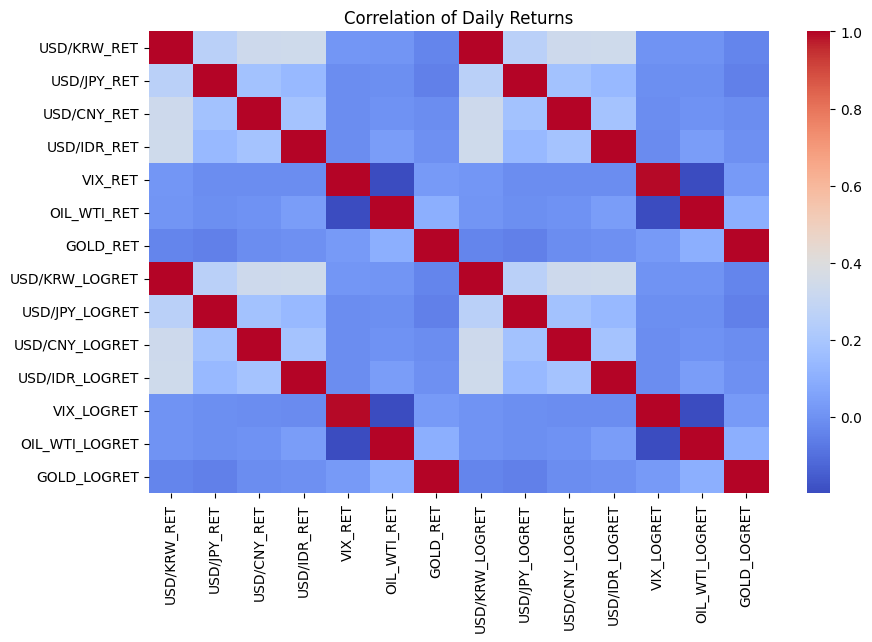

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(feature_df[[col for col in feature_df.columns if "RET" in col]].corr(),
            annot=False, cmap='coolwarm')
plt.title("Correlation of Daily Returns")
plt.show()

## 3.4. FX 30-Day Volatility Trend

In [14]:
vol_cols = [col for col in feature_df.columns if "USD" in col and "VOL30" in col]

fig = px.line(
    feature_df[vol_cols],
    title="30-Day Rolling Volatility (FX Pairs)",
    labels={"value": "Volatility", "index": "Date"}
)
fig.show()

## 3.5. Macro Risk Indices Visualization

In [15]:
fig = px.line(
    feature_df[["FX_RISK", "COMMODITY_RISK", "FEAR_INDEX"]],
    title="Macro Risk Composite Indicators",
    labels={"value": "Risk Level", "index": "Date"}
)
fig.show()

## 3.6. Combine FX + VIX in One Chart

In [16]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df.index,
    y=df["USD/KRW"],
    name="USD/KRW",
    yaxis="y1"
))

fig.add_trace(go.Scatter(
    x=df.index,
    y=df["VIX"],
    name="VIX",
    yaxis="y2"
))

fig.update_layout(
    title="USD/KRW vs VIX (Dual Axis)",
    yaxis=dict(title="USD/KRW"),
    yaxis2=dict(title="VIX", overlaying="y", side="right"),
    legend=dict(x=0.1, y=1)
)

fig.show()

# 4. PCA — Hidden Macro Factors

## 4.1 Select Features for PCA

In [17]:
# Select relevant columns (log returns + vol + macro factors)
pca_cols = [col for col in feature_df.columns if "LOGRET" in col or "VOL30" in col] + \
           ["FX_RISK", "COMMODITY_RISK", "FEAR_INDEX"]

pca_df = feature_df[pca_cols].dropna()
pca_df.head()

,USD/KRW_LOGRET,USD/JPY_LOGRET,USD/CNY_LOGRET,USD/IDR_LOGRET,VIX_LOGRET,OIL_WTI_LOGRET,GOLD_LOGRET,USD/KRW_VOL30,USD/JPY_VOL30,USD/CNY_VOL30,USD/IDR_VOL30,VIX_VOL30,OIL_WTI_VOL30,GOLD_VOL30,FX_RISK,COMMODITY_RISK,FEAR_INDEX
Date,,,,,,,,,,,,,,,,,
2015-02-13,-0.004078,-0.010490,0.000353,-0.002737,-0.043297,0.030198,0.005232,0.100824,0.117599,0.023341,0.094431,1.335365,0.667031,0.178161,0.005118,0.027112,-0.510324
2015-02-16,-0.005281,-0.002914,-0.000674,-0.007309,0.000000,0.000000,0.000000,0.090546,0.116875,0.023474,0.095497,1.286787,0.648820,0.173256,0.005027,0.027112,-0.510324
2015-02-17,0.004372,-0.000658,0.001331,-0.004903,0.072843,0.014110,-0.015116,0.091444,0.114460,0.023113,0.090773,1.294089,0.635497,0.175142,0.005049,0.026101,-0.354205
2015-02-18,0.006433,0.006024,0.000881,0.012369,-0.022401,-0.026310,-0.006977,0.088420,0.114375,0.022919,0.097623,1.272501,0.640380,0.175081,0.005136,0.026266,-0.403432
2015-02-19,0.000271,-0.004363,0.000000,0.002971,-0.010410,-0.018974,0.006149,0.088419,0.114073,0.022926,0.096102,1.221292,0.643336,0.176001,0.004994,0.026055,-0.425935


## 4.2 Standardize Data

In [18]:
scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_df)

## 4.3 Run PCA (Keep 3 Components)

In [19]:
pca = PCA(n_components=3)
pca_components = pca.fit_transform(pca_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.23119958 0.10653073 0.1005481 ]


## 4.4 Create PCA DataFrame

In [20]:
pca_df_out = pd.DataFrame(
    pca_components,
    index=pca_df.index,
    columns=["FACTOR_1", "FACTOR_2", "FACTOR_3"]
)

pca_df_out.head()

,FACTOR_1,FACTOR_2,FACTOR_3
Date,,,
2015-02-13,1.378294,0.664553,-1.239840
2015-02-16,1.072241,0.597763,-1.328940
2015-02-17,1.011199,-0.417037,0.138117
2015-02-18,1.000349,-1.277453,1.762038
2015-02-19,0.993645,-0.093679,-0.256525


## 4.5 Plot PCA Factors (Time Series)

Factor 1 (Global Macro Stress Driver)

In [21]:
fig = px.line(
    pca_df_out["FACTOR_1"],
    title="PCA Macro Factor 1 – Global Macro Stress",
    labels={"value": "Factor Value", "index": "Date"}
)
fig.show()

Factor 2 (FX-Specific Driver)

In [22]:
fig = px.line(
    pca_df_out["FACTOR_2"],
    title="PCA Macro Factor 2 – FX-Specific Movements",
    labels={"value": "Factor Value", "index": "Date"}
)
fig.show()

Factor 3 (Commodity-Driven Factor)

In [23]:
fig = px.line(
    pca_df_out["FACTOR_3"],
    title="PCA Macro Factor 3 – Commodity & VIX Influence",
    labels={"value": "Factor Value", "index": "Date"}
)
fig.show()

## 4.6 Explained Variance Plot

In [24]:
fig = px.bar(
    x=[1,2,3],
    y=pca.explained_variance_ratio_,
    title="Explained Variance by PCA Components",
    labels={"x": "Principal Component", "y": "Variance Contribution"}
)
fig.show()

## 4.7 PCA Loadings (Feature Contributions)

In [25]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_df.columns,
    columns=["FACTOR_1", "FACTOR_2", "FACTOR_3"]
)

loadings.sort_values("FACTOR_1", ascending=False).head(10)

,FACTOR_1,FACTOR_2,FACTOR_3
FX_RISK,0.415540,0.229421,0.146671
OIL_WTI_VOL30,0.383723,-0.224337,-0.140631
GOLD_VOL30,0.380930,-0.120098,-0.081259
USD/KRW_VOL30,0.325317,0.375263,0.234024
FEAR_INDEX,0.322585,-0.233693,-0.086600
USD/IDR_VOL30,0.316191,-0.210716,-0.143005
USD/JPY_VOL30,0.298164,0.367084,0.244703
COMMODITY_RISK,0.296782,-0.233199,-0.155290
VIX_VOL30,0.188461,-0.171018,-0.079952
USD/CNY_VOL30,0.104511,0.381081,0.231881


## 4.8 Merge PCA Factors into Master Dataset

In [26]:
full_df = feature_df.join(pca_df_out, how="inner")
full_df.to_csv("global_market_master.csv")

full_df

,USD/KRW,USD/JPY,USD/CNY,USD/IDR,VIX,OIL_WTI,GOLD,USD/KRW_RET,USD/JPY_RET,USD/CNY_RET,...,USD/IDR_VOL30,VIX_VOL30,OIL_WTI_VOL30,GOLD_VOL30,FX_RISK,COMMODITY_RISK,FEAR_INDEX,FACTOR_1,FACTOR_2,FACTOR_3
Date,,,,,,,,,,,,,,,,,,,,,
2015-02-13,1101.199951,118.916000,6.2345,12770.000000,14.69,52.779999,1226.500000,-0.004070,-0.010435,0.000353,...,0.094431,1.335365,0.667031,0.178161,0.005118,0.027112,-0.510324,1.378294,0.664553,-1.239840
2015-02-16,1095.400024,118.570000,6.2303,12677.000000,14.69,52.779999,1226.500000,-0.005267,-0.002910,-0.000674,...,0.095497,1.286787,0.648820,0.173256,0.005027,0.027112,-0.510324,1.072241,0.597763,-1.328940
2015-02-17,1100.199951,118.491997,6.2386,12615.000000,15.80,53.529999,1208.099976,0.004382,-0.000658,0.001332,...,0.090773,1.294089,0.635497,0.175142,0.005049,0.026101,-0.354205,1.011199,-0.417037,0.138117
2015-02-18,1107.300049,119.208000,6.2441,12772.000000,15.45,52.139999,1199.699951,0.006453,0.006043,0.000882,...,0.097623,1.272501,0.640380,0.175081,0.005136,0.026266,-0.403432,1.000349,-1.277453,1.762038
2015-02-19,1107.599976,118.689003,6.2441,12810.000000,15.29,51.160000,1207.099976,0.000271,-0.004354,0.000000,...,0.096102,1.221292,0.643336,0.176001,0.004994,0.026055,-0.425935,0.993645,-0.093679,-0.256525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-02,1470.170044,155.557007,7.0717,16609.000000,16.59,58.639999,4186.600098,0.003105,-0.002379,-0.000481,...,0.159903,1.150726,0.271834,0.192836,0.003451,0.013581,-0.243093,-0.160780,-0.801137,-0.516007
2025-12-03,1467.359985,155.807007,7.0700,16609.900391,16.08,58.950001,4199.299805,-0.001911,0.001607,-0.000240,...,0.159597,1.146374,0.270162,0.189833,0.003163,0.013394,-0.314823,-0.318344,-0.826052,-0.753037
2025-12-04,1465.030029,155.106995,7.0636,16594.000000,15.78,59.669998,4211.799805,-0.001588,-0.004493,-0.000905,...,0.159621,1.129303,0.218902,0.181585,0.003190,0.013504,-0.357018,-0.437206,-0.419305,-1.209983


# 5. Multivariate LSTM Forecasting

In [27]:
data = full_df.copy()
target = "USD/KRW"

## 5.1 Scaling

In [28]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

scaled_df = pd.DataFrame(scaled_data, columns=data.columns, index=data.index)

## 5.2 Sequences (lookback = 30 days)

In [29]:
def create_sequences(df, target_col, lookback=30):
    X, y = [], []
    for i in range(lookback, len(df)):
        X.append(df.iloc[i-lookback:i].values)
        y.append(df.iloc[i][target_col])
    return np.array(X), np.array(y)

LOOKBACK = 30
X, y = create_sequences(scaled_df, target_col=target, lookback=LOOKBACK)

print("X shape:", X.shape)  # (samples, 30, features)
print("y shape:", y.shape)

X shape: (2788, 30, 34)
y shape: (2788,)


## 5.3 Data Splitting

In [30]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## 5.4 LSTM Model

In [31]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, X.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        25,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,305 (149.63 KB)

 Trainable params: 38,305 (149.63 KB)

 Non-trainable params: 0 (0.00 B)

## 5.5 Model Training

In [32]:
es = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=40,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

Epoch 1/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - loss: 0.0400 - val_loss: 0.0069
Epoch 2/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0051 - val_loss: 0.0034
Epoch 3/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0033 - val_loss: 0.0147
Epoch 4/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0030 - val_loss: 0.0053
Epoch 5/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0022 - val_loss: 0.0114
Epoch 6/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0023 - val_loss: 0.0034
Epoch 7/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0016 - val_loss: 0.0028
Epoch 8/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0015 - val_loss: 0.0019
Epoch 9/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0014 - val_loss: 0.0028
Epoch 10/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0014 - val_loss: 0.0027
Epoch 11/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0012 - val_loss: 0.0041
Epoch 12/40
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.

## 5.6 Predict & Inverse Transform

In [33]:
y_pred = model.predict(X_test)

# Temp df for inverse scaling
temp = np.zeros((len(y_pred), scaled_df.shape[1]))
temp[:, scaled_df.columns.get_loc(target)] = y_pred[:, 0]

inversed = scaler.inverse_transform(temp)[:, scaled_df.columns.get_loc(target)]
y_pred_real = inversed

# Real values
temp_real = np.zeros((len(y_test), scaled_df.shape[1]))
temp_real[:, scaled_df.columns.get_loc(target)] = y_test
y_real = scaler.inverse_transform(temp_real)[:, scaled_df.columns.get_loc(target)]

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


## 5.7 Real vs Prediction Plot

In [34]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=y_real, mode="lines", name="Real"))
fig.add_trace(go.Scatter(y=y_pred_real, mode="lines", name="Predicted"))
fig.update_layout(title="LSTM Forecasting for USD/KRW")
fig.show()

# 6. Country Exposure & Macro Risk Scoring

## 6.1 Select Risk Features

In [35]:
risk_features = [
    "FX_RISK",
    "COMMODITY_RISK",
    "FEAR_INDEX",
    "FACTOR_1",
    "FACTOR_2",
    "FACTOR_3",
    "USD/KRW_VOL30",
    "USD/JPY_VOL30",
    "USD/CNY_VOL30",
    "USD/IDR_VOL30"
]

risk_df = full_df[risk_features].copy()
risk_df.tail()

,FX_RISK,COMMODITY_RISK,FEAR_INDEX,FACTOR_1,FACTOR_2,FACTOR_3,USD/KRW_VOL30,USD/JPY_VOL30,USD/CNY_VOL30,USD/IDR_VOL30
Date,,,,,,,,,,
2025-12-02,0.003451,0.013581,-0.243093,-0.160780,-0.801137,-0.516007,0.083041,0.066179,0.031879,0.159903
2025-12-03,0.003163,0.013394,-0.314823,-0.318344,-0.826052,-0.753037,0.081104,0.063419,0.031837,0.159597
2025-12-04,0.003190,0.013504,-0.357018,-0.437206,-0.419305,-1.209983,0.081355,0.065285,0.031802,0.159621
2025-12-05,0.003124,0.013521,-0.409058,-0.515601,-1.306872,0.256633,0.081816,0.064408,0.032050,0.159968
2025-12-08,0.003054,0.013023,-0.233247,-0.681017,-0.825464,-0.471399,0.081893,0.064030,0.032028,0.160034


## 6.2 Normalize each risk factor (0–1)

In [36]:
scaler_risk = MinMaxScaler()
risk_norm = scaler_risk.fit_transform(risk_df)

risk_norm_df = pd.DataFrame(
    risk_norm,
    index=risk_df.index,
    columns=[col + "_NORM" for col in risk_df.columns]
)

risk_norm_df.tail()

,FX_RISK_NORM,COMMODITY_RISK_NORM,FEAR_INDEX_NORM,FACTOR_1_NORM,FACTOR_2_NORM,FACTOR_3_NORM,USD/KRW_VOL30_NORM,USD/JPY_VOL30_NORM,USD/CNY_VOL30_NORM,USD/IDR_VOL30_NORM
Date,,,,,,,,,,
2025-12-02,0.118329,0.019848,0.101292,0.193381,0.388191,0.412320,0.279644,0.200594,0.194394,0.505120
2025-12-03,0.089976,0.019353,0.094358,0.183829,0.386461,0.391451,0.268200,0.183055,0.194094,0.504024
2025-12-04,0.092583,0.019646,0.090279,0.176624,0.414708,0.351222,0.269681,0.194910,0.193845,0.504113
2025-12-05,0.086102,0.019689,0.085248,0.171872,0.353070,0.480343,0.272405,0.189340,0.195604,0.505352
2025-12-08,0.079145,0.018374,0.102243,0.161845,0.386502,0.416247,0.272860,0.186936,0.195452,0.505590


## 6.3 Create Weighted Macro Risk Score

In [37]:
risk_norm_df["MACRO_RISK_SCORE"] = (
    0.30 * risk_norm_df["FACTOR_1_NORM"] +
    0.20 * risk_norm_df["FX_RISK_NORM"] +
    0.10 * risk_norm_df["COMMODITY_RISK_NORM"] +
    0.20 * risk_norm_df["FEAR_INDEX_NORM"] +
    0.05 * risk_norm_df["FACTOR_2_NORM"] +
    0.05 * risk_norm_df["FACTOR_3_NORM"] +
    0.03 * risk_norm_df["USD/KRW_VOL30_NORM"] +
    0.03 * risk_norm_df["USD/JPY_VOL30_NORM"] +
    0.02 * risk_norm_df["USD/CNY_VOL30_NORM"] +
    0.02 * risk_norm_df["USD/IDR_VOL30_NORM"]
)

risk_norm_df["MACRO_RISK_SCORE"].tail()

,MACRO_RISK_SCORE
Date,
2025-12-02,0.172346
2025-12-03,0.160346
2025-12-04,0.157717
2025-12-05,0.157343
2025-12-08,0.154621


## 6.4 Create Opportunity Score

* Low risk
* Low volatility
* Stable FX
* Low fear index
* Strong PCA Factor_2 (FX stability)

In [38]:
risk_norm_df["OPPORTUNITY_SCORE"] = (
    1 - risk_norm_df["MACRO_RISK_SCORE"] +
    0.10 * (1 - risk_norm_df["FEAR_INDEX_NORM"]) +
    0.10 * (1 - risk_norm_df["USD/KRW_VOL30_NORM"])
)

## 6.5 Smooth Using Rolling Mean (Bank-style)

In [39]:
risk_norm_df["MACRO_RISK_SMOOTH"] = risk_norm_df["MACRO_RISK_SCORE"].rolling(10).mean()
risk_norm_df["OPPORTUNITY_SMOOTH"] = risk_norm_df["OPPORTUNITY_SCORE"].rolling(10).mean()

## 6.6 Visualize Macro Risk Score

In [40]:
fig = px.line(
    risk_norm_df["MACRO_RISK_SMOOTH"],
    title="Macro Risk Score (Smoothed)",
    labels={"value": "Risk Score", "index": "Date"}
)
fig.show()

## 6.7 Visualize Opportunity Score

In [41]:
fig = px.line(
    risk_norm_df["OPPORTUNITY_SMOOTH"],
    title="Opportunity Score (Smoothed)",
    labels={"value": "Opportunity", "index": "Date"}
)
fig.show()

## 6.8 Create Traffic-Light Labels (for Dashboard)

In [42]:
risk_norm_df["RISK_LEVEL"] = pd.cut(
    risk_norm_df["MACRO_RISK_SMOOTH"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=["LOW", "MEDIUM", "HIGH"]
)

In [43]:
risk_norm_df[["MACRO_RISK_SMOOTH", "RISK_LEVEL"]].tail()

,MACRO_RISK_SMOOTH,RISK_LEVEL
Date,,
2025-12-02,0.244777,LOW
2025-12-03,0.232544,LOW
2025-12-04,0.218739,LOW
2025-12-05,0.205831,LOW
2025-12-08,0.193981,LOW


## 6.9 Merge Back into Master Dataset

In [44]:
final_df = full_df.join(risk_norm_df, how="left")
final_df.to_csv("global_market_final.csv")

final_df.tail()

,USD/KRW,USD/JPY,USD/CNY,USD/IDR,VIX,OIL_WTI,GOLD,USD/KRW_RET,USD/JPY_RET,USD/CNY_RET,...,FACTOR_3_NORM,USD/KRW_VOL30_NORM,USD/JPY_VOL30_NORM,USD/CNY_VOL30_NORM,USD/IDR_VOL30_NORM,MACRO_RISK_SCORE,OPPORTUNITY_SCORE,MACRO_RISK_SMOOTH,OPPORTUNITY_SMOOTH,RISK_LEVEL
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-02,1470.170044,155.557007,7.0717,16609.000000,16.59,58.639999,4186.600098,0.003105,-0.002379,-0.000481,...,0.412320,0.279644,0.200594,0.194394,0.505120,0.172346,0.989560,0.244777,0.913980,LOW
2025-12-03,1467.359985,155.807007,7.0700,16609.900391,16.08,58.950001,4199.299805,-0.001911,0.001607,-0.000240,...,0.391451,0.268200,0.183055,0.194094,0.504024,0.160346,1.003398,0.232544,0.927105,LOW
2025-12-04,1465.030029,155.106995,7.0636,16594.000000,15.78,59.669998,4211.799805,-0.001588,-0.004493,-0.000905,...,0.351222,0.269681,0.194910,0.193845,0.504113,0.157717,1.006287,0.218739,0.942236,LOW
2025-12-05,1472.380005,155.141998,7.0714,16654.400391,15.41,60.080002,4212.899902,0.005017,0.000226,0.001104,...,0.480343,0.272405,0.189340,0.195604,0.505352,0.157343,1.006892,0.205831,0.956119,LOW
2025-12-08,1471.810059,155.339996,7.0696,16683.000000,16.66,58.740002,4218.700195,-0.000387,0.001276,-0.000255,...,0.416247,0.272860,0.186936,0.195452,0.505590,0.154621,1.007869,0.193981,0.968392,LOW


# 7. Deployment

In [45]:
import joblib
import os

# Create model directory (if not exists)
os.makedirs("model", exist_ok=True)

model.save("model/lstm_model.h5")
print("LSTM model saved!")

joblib.dump(scaler, "model/scaler.pkl")
print("Scaler saved!")

LSTM model saved!
Scaler saved!
